# 03 — What I found

This notebook walks through the results of asking three open-weights VLMs my 3,451 parking questions twice: once showing them the sign (**condition A**), and once handing them my transcription of it as text (**condition B**). The difference between the two is the question the whole project asks: when a model gets a parking sign wrong, is it because it couldn't *read* the sign, or couldn't *reason* about it?

Every number comes from `src/vlm_parking/analysis.py`, and every interval is a 95% bootstrap over **signs**, not queries. A sign's ~15 questions share one image and one transcription, so they aren't independent; resampling queries would pretend I have 3,451 independent observations and report intervals several times too narrow. `scripts/analyze.py` writes the same tables and figures to `reports/phase6/` in one command.

**The short version**

1. All three models clear the 57.4% "always say illegal" baseline comfortably, in both conditions.
2. Reading the sign instead of being told what it says costs Qwen3-VL and MiniCPM-V about 8–9 points. InternVL appears to lose almost nothing.
3. That last result is misleading. Counting only the questions each model got **right from the text**, all three get a real share **wrong from the image**: 13.6% for Qwen, 18.0% for InternVL, 18.1% for MiniCPM. InternVL's gap looks small because it also gets many questions *right from the image* that it got wrong from the text, and the two cancel.
4. Those losses climb steeply with how complex the sign is, for every model: from 10–14% on single-panel signs to 24–33% on signs with three or more.
5. **But most of them aren't misreading.** Reading 50 by hand, only about one in eight is a genuine misread: a wrong day, a missed panel. Most are the model quoting the sign correctly and then misunderstanding it or reasoning badly. The most common misunderstanding is treating any hour the sign doesn't mention as forbidden. My text transcription (condition B) quietly does that interpreting for the model, so the A−B gap measures reading, interpreting *and* reasoning over a real sign, not eyesight alone.
6. Giving a model more of the image didn't help. InternVL spends over 2,000 more tokens per sign than the others on the same crop, and loses at least as much.

In [1]:
import sys
from pathlib import Path

SRC = Path("../src").resolve()          # import vlm_parking even if this kernel isn't the project venv
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import pandas as pd
from IPython.display import display

from vlm_parking import analysis as an
from vlm_parking import figures as fg

%config InlineBackend.figure_format = "retina"
pd.set_option("display.max_colwidth", 120)

DATA = Path("../data")
queries = pd.read_parquet(DATA / "queries/queries_v1.parquet")
signs = pd.read_parquet(DATA / "queries/signs_v1.parquet")
d = an.load_scored(DATA / "runs", queries, signs)   # refuses to score runs that don't match the query set

legal = queries.verdict.eq("legal").mean()
majority = max(legal, 1 - legal)
print(f"{len(d):,} answers: 3 models x 2 conditions x {len(queries):,} queries over {queries.sign_id.nunique()} signs")
print(f"{legal:.1%} of queries are legal, so always answering 'illegal' scores {majority:.1%}")

20,706 answers: 3 models x 2 conditions x 3,451 queries over 234 signs
42.6% of queries are legal, so always answering 'illegal' scores 57.4%


## 1. The runs themselves

Before any accuracy number, I check that the runs are what I think they are. `run_inference.py` records provenance in every row and in a manifest, one line per run: every one of the six should share an engine version and GPU, and each model should be pinned to the same commit in both conditions. If any of that differed, an A−B difference could be an artifact of the setup rather than of the model.

In [2]:
manifest = pd.read_json(DATA / "runs/manifest.jsonl", lines=True)
manifest.assign(model_revision=manifest.model_revision.str[:10])[
    ["model", "condition", "n_run", "parse_failures", "seconds", "vllm_version", "gpu", "model_revision",
     "grammar_whitespace", "max_tokens"]]

,model,condition,n_run,parse_failures,seconds,vllm_version,gpu,model_revision,grammar_whitespace,max_tokens
0,qwen3-vl-8b,B,3451,7,101.3,0.29.0,NVIDIA A100-SXM4-40GB,0c351dd01e,locked,512
1,internvl3_5-8b,B,3451,0,65.8,0.29.0,NVIDIA A100-SXM4-40GB,9bb6a56ad9,locked,512
2,minicpm-v-4_5,B,3451,1,99.7,0.29.0,NVIDIA A100-SXM4-40GB,daef484c35,locked,512
3,qwen3-vl-8b,A,3451,1,108.4,0.29.0,NVIDIA A100-SXM4-40GB,0c351dd01e,locked,512
4,internvl3_5-8b,A,3451,0,185.6,0.29.0,NVIDIA A100-SXM4-40GB,9bb6a56ad9,locked,512
5,minicpm-v-4_5,A,3451,4,113.6,0.29.0,NVIDIA A100-SXM4-40GB,daef484c35,locked,512


Six runs, one engine (vLLM 0.29.0), one GPU, and each model on the same weights in both conditions. The whole matrix took about 11 minutes of GPU time; almost all of the rental went to downloading and loading models.

Thirteen answers out of 20,706 failed to parse. Guided decoding holds output to my JSON schema, so these aren't formatting errors. The seven in Qwen's condition-B run are the ones I looked at: six are Qwen computing `07:16 + 45 minutes = 07:61`, failing to carry the minutes into the hour, and repeating itself until it ran out of tokens. I score every parse failure as **wrong** rather than dropping it, since dropping would quietly remove a model's hardest questions from its own denominator.

## 2. The headline: what does reading the sign cost?

In [3]:
overall = an.accuracy_table(d).set_index(["model", "condition"])
gaps = an.paired_gap(d).set_index("model")
pd.DataFrame([{
    "model": fg.NAMES[m],
    "B · text": fg.ci(*overall.loc[(m, "B"), ["est", "lo", "hi"]]),
    "A · image": fg.ci(*overall.loc[(m, "A"), ["est", "lo", "hi"]]),
    "A − B": fg.pts(*gaps.loc[m, ["gap", "lo", "hi"]]),
} for m in an.MODELS]).set_index("model")

,B · text,A · image,A − B
model,,,
Qwen3-VL-8B,"91.3% [90.0, 92.5]","82.4% [80.4, 84.3]","−8.9 pts [−10.8, −7.1]"
InternVL3.5-8B,"78.9% [76.9, 81.0]","77.9% [75.4, 80.5]","−0.9 pts [−3.4, +1.8]"
MiniCPM-V-4.5,"84.4% [82.6, 86.2]","76.3% [74.0, 78.6]","−8.1 pts [−10.4, −5.8]"


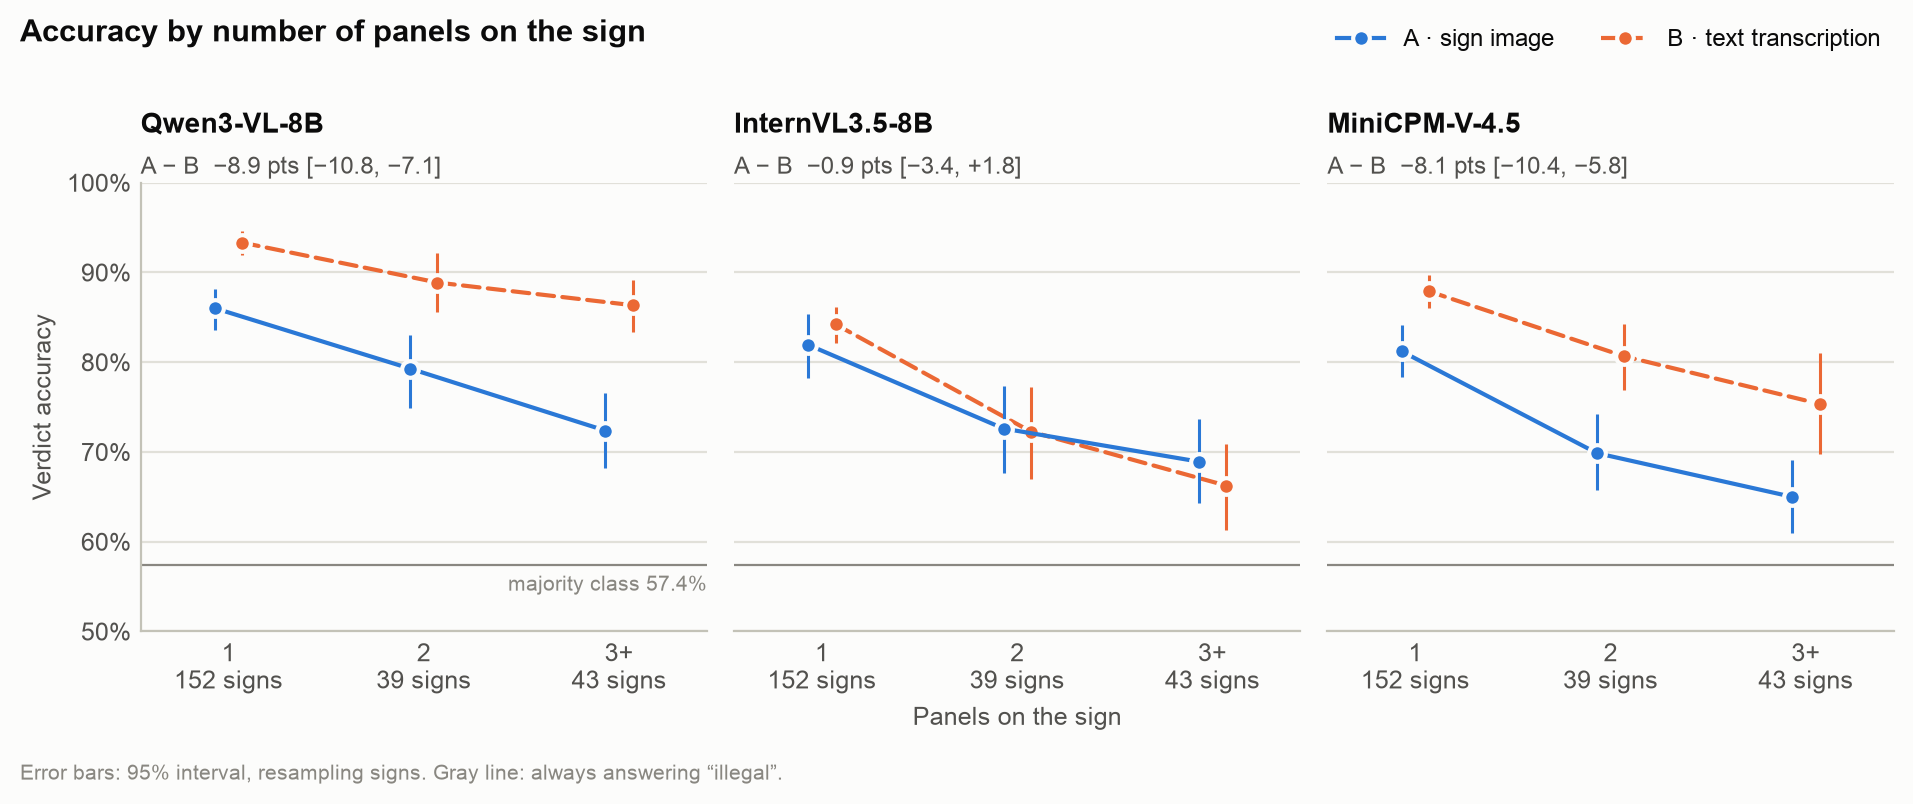

In [4]:
by_panels = an.accuracy_table(d, "panels")
fg.accuracy_by_panels(by_panels, an.paired_gap(d), majority);

Two things stand out.

**Complexity hurts in both conditions.** Every line falls from left to right, including the dashed ones: even handed a clean transcription, all three models get worse as a sign gains panels. Part of what makes multi-panel signs hard is reasoning, not reading.

**The gap differs sharply by model.** Qwen and MiniCPM lose 8–9 points when they have to read the sign, and the gap widens on complex signs. InternVL's two lines lie almost on top of each other, and its interval on the gap includes zero. Read at face value, InternVL reads signs about as well as it reasons about them.

The next section shows that face value is wrong.

## 3. What the gap is made of

The A − B gap is a *net* number. Each question lands in one of four cells, depending on whether the model got it right from the text and from the image:

| | right from the image | wrong from the image |
|---|---|---|
| **right from the text** | both right | **lost on the image** |
| **wrong from the text** | **rescued by the image** | both wrong |

Both conditions ask the same questions, so the gap is exactly *rescues minus losses*, as a share of all questions. A model that is often wrong from the text has more questions available to be rescued, which can shrink its gap without it handling the image any better. A cleaner measure is the loss rate: of the questions a model answered correctly when handed the rules, how many it gets wrong when it has to read them. It demonstrably could apply the rules to those, so something went wrong between the picture and the answer. Section 4 reads 50 of these by hand to find out what.

In [5]:
decomp = an.perception_decomposition(d).set_index("model")
pd.DataFrame([{
    "model": fg.NAMES[m],
    "both right": decomp.loc[m, "both_right"],
    "lost on image": decomp.loc[m, "lost_on_image"],
    "rescued by image": decomp.loc[m, "rescued_by_image"],
    "both wrong": decomp.loc[m, "both_wrong"],
    "P(wrong on image | right on text)": fg.ci(*decomp.loc[m, ["p_loss", "p_loss_lo", "p_loss_hi"]]),
    "P(right on image | wrong on text)": fg.ci(*decomp.loc[m, ["p_rescue", "p_rescue_lo", "p_rescue_hi"]]),
} for m in an.MODELS]).set_index("model")

,both right,lost on image,rescued by image,both wrong,P(wrong on image | right on text),P(right on image | wrong on text)
model,,,,,,
Qwen3-VL-8B,2723,427,119,182,"13.6% [11.7, 15.6]","39.5% [33.7, 45.9]"
InternVL3.5-8B,2231,491,459,270,"18.0% [15.6, 20.6]","63.0% [58.1, 67.6]"
MiniCPM-V-4.5,2383,528,250,290,"18.1% [15.6, 20.7]","46.3% [41.5, 50.9]"


InternVL loses **18.0%** of the questions it got right from the text, the same as MiniCPM and more than Qwen. Its net gap is near zero because it also *rescues* 459 questions, 63% of the ones it got wrong from the text, and its losses and rescues nearly cancel. So InternVL's small gap is not a sign that it copes well with images: it answers the same question differently depending on how the sign is presented, in both directions.

Here is the loss rate by sign complexity, laid out like the figure above so the two can be read side by side:

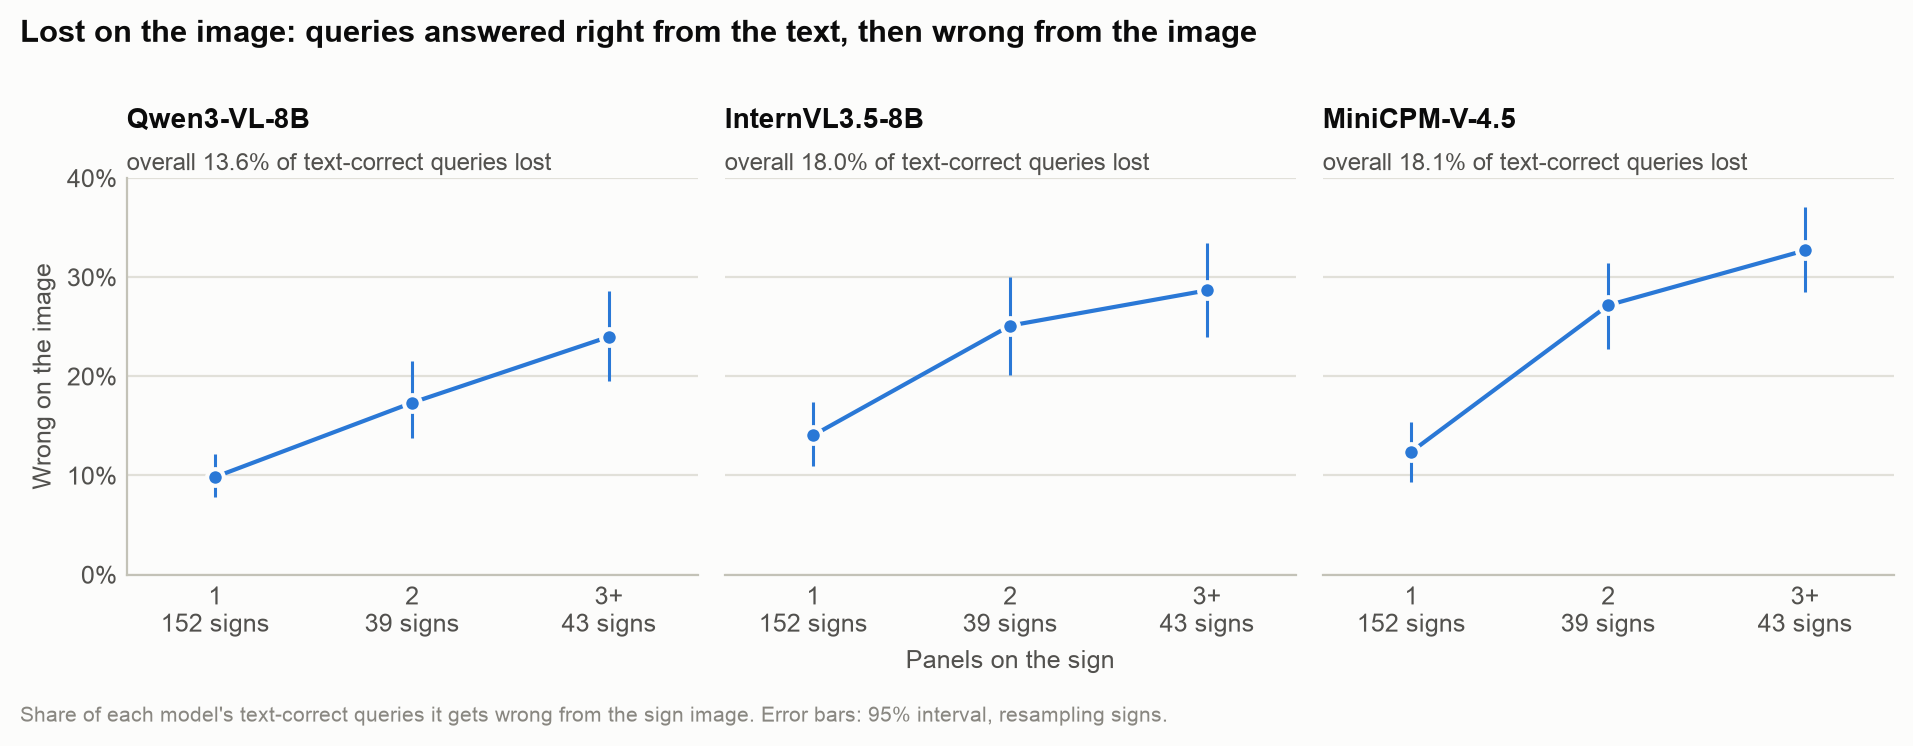

In [6]:
fg.perception_loss_by_panels(an.perception_decomposition(d, "panels"));

For every model, the share of questions lost on the image **roughly doubles or triples** from single-panel signs to signs with three or more panels. InternVL, flat in the first figure, climbs with the other two here. Qwen loses the fewest at every level of complexity.

## 4. What the losses actually are

The loss rate says *that* something goes wrong between the picture and the answer, not *what*. So I read 50 of these losses by hand: condition-A failures where the same model got the question right from the text, split evenly across the three models. For each, I compared the model's stated reasoning against the sign. The deciding question is whether the model **quoted the sign correctly**. If it did, the error isn't a misread, whatever else it is.

Each failure gets one tag, in one of four families:

- **perception**: misread what the sign says (a wrong day, a missed or merged panel, a missed exception)
- **interpretation**: read it correctly, misunderstood what it means
- **reasoning**: read and understood it, then got the logic wrong
- **ambiguous**: can't tell from the image whether the model or my label is right

The tags live in `data/labels/error_tags.csv`, with a one-line note per failure explaining the call.

In [7]:
tags = pd.read_csv(DATA / "labels/error_tags.csv", keep_default_na=False)
print(f"tagged by: {tags.tagged_by.value_counts().to_dict()} | reviewed: {tags.reviewed.ne('').sum()} of {len(tags)}")

fam = an.tag_families(tags)            # also validates every tag against the taxonomy
overall = fam[fam.model == "all"].set_index("family")
per_model = fam[fam.model != "all"].pivot(index="family", columns="model", values="n").reindex(an.FAMILIES)
pd.DataFrame({
    "failures": overall.n,
    "share of the 50": [fg.ci(*overall.loc[f, ["est", "lo", "hi"]]) for f in an.FAMILIES],
    **{fg.NAMES[m]: per_model[m] for m in an.MODELS},
}, index=pd.Index(an.FAMILIES, name="family"))

tagged by: {'claude': 50} | reviewed: 0 of 50


,failures,share of the 50,Qwen3-VL-8B,InternVL3.5-8B,MiniCPM-V-4.5
family,,,,,
perception,6,"12.0% [4.1, 21.2]",2,3,1
interpretation,15,"30.0% [17.8, 42.6]",5,4,6
reasoning,28,"56.0% [42.0, 70.0]",9,9,10
ambiguous,1,"2.0% [0.0, 6.2]",0,1,0


**Only about one in eight is a genuine misread.** With 50 cases the interval is wide, but even its top end leaves most losses unexplained by eyesight. More than half are reasoning errors made *after* reading the sign correctly. The per-model columns rest on about 17 failures each, too few to compare the models.

In [8]:
counts = tags.groupby(["family", "tag"]).size().rename("failures").reset_index()
counts["family"] = pd.Categorical(counts.family, an.FAMILIES, ordered=True)
counts["also as secondary"] = counts.tag.map(tags.tag2[tags.tag2 != ""].value_counts()).fillna(0).astype(int)
counts.sort_values(["family", "failures"], ascending=[True, False]).set_index(["family", "tag"])

failures  also as secondary
family         tag                                                
perception     dropped panel                  3                  0
               merged panels                  1                  0
               misread day                    1                  1
               missed exception               1                  0
interpretation default-deny                  13                  6
               exemption inverted             2                  1
reasoning      time comparison               13                  1
               ignored time limit             6                  0
               day-only reasoning             3                  0
               arrival-only reasoning         2                  0
               boundary error                 2                  0
               ignored panel                  1                  0
               other reasoning                1                  1
ambiguous      ambiguous legibility           1                  0

Two failures dominate.

**Default-deny** is the biggest single misunderstanding. The models treat a sign as a list of the only times parking is allowed. "2 HOUR PARKING 8AM TO 8PM" limits how long you can stay *between* those hours and says nothing about the rest, but the models read it as "parking only 8 AM–8 PM" and rule a 3 AM arrival illegal. One spelled the logic out: *"the sign does not explicitly allow parking after 7 PM on Friday."* My prompt says the opposite, that no rule applies except what the sign posts. The models follow it when handed my transcription, which names the rule ("Time-limited parking; limit 120 minutes"). Facing the sign itself, they don't.

**Time comparison** is the commonest reasoning error: *"the driver arrives at 16:58 (4:58 PM), which is after 6 PM."* The model converts the time correctly, then misjudges which side of the window it falls on.

Four examples: a misread day, a dropped panel, default-deny, and a clock error.

In [9]:
example_rows = [4, 28, 41, 46]   # a misread day, a dropped panel, default-deny, a clock error
tags.loc[example_rows, ["model", "family", "tag", "question", "reason_on_image", "notes"]]

,model,family,tag,question,reason_on_image,notes
4,internvl3_5-8b,perception,misread day,FRI 06:45 for 90 min,Parking is not allowed from 8 AM to 10 AM on Fridays due to street cleaning.,Read TUESDAY (legible) as Friday.
28,minicpm-v-4_5,perception,dropped panel,THU 11:34 for 45 min,"The driver arrives at 11:34, which is outside the specified no stopping times of 7-9 AM and 4-6 PM. Since the driver...",Never mentions the legible NO PARKING ANY TIME panel beneath the no-stopping panel.
41,qwen3-vl-8b,interpretation,default-deny,FRI 21:18 for 90 min,"The driver arrives at 21:18 on Friday, which is outside the 4 PM to 7 PM no stopping zone. The sign allows 2-hour pa...",'The sign does not explicitly allow parking after 7 PM on Friday.'
46,qwen3-vl-8b,reasoning,time comparison,MON 16:58 for 60 min,"The sign indicates 1 hour parking from 8 AM to 6 PM, except Sunday. The driver arrives at 16:58 (4:58 PM) on Monday,...",Said 16:58 (4:58 PM) is after 6 PM.


The clock errors suggested a cause: my questions give times on a 24-hour clock ("16:58"), while signs use a 12-hour one ("4 PM"), and my transcription is 24-hour too, so only the image forces a conversion. If that were driving the losses, afternoon arrivals, where the digits differ between the two clocks, should be lost more often than morning ones. Checking on every question, not just the 50:

In [10]:
hour = d.time.str[:2].astype(int)
d["arrival"] = pd.Categorical(pd.cut(hour, [-1, 11, 12, 24], labels=["morning", "noon hour", "afternoon"]),
                              ["morning", "noon hour", "afternoon"], ordered=True)
by_clock = an.perception_decomposition(d, "arrival").set_index(["model", "arrival"])
pd.DataFrame([{
    "model": fg.NAMES[m],
    "lost on image · morning": fg.ci(*by_clock.loc[(m, "morning"), ["p_loss", "p_loss_lo", "p_loss_hi"]]),
    "lost on image · afternoon": fg.ci(*by_clock.loc[(m, "afternoon"), ["p_loss", "p_loss_lo", "p_loss_hi"]]),
} for m in an.MODELS]).set_index("model")

,lost on image · morning,lost on image · afternoon
model,,
Qwen3-VL-8B,"14.6% [12.3, 16.9]","13.1% [10.5, 15.5]"
InternVL3.5-8B,"17.6% [14.7, 20.5]","19.1% [15.8, 22.6]"
MiniCPM-V-4.5,"15.9% [13.2, 18.7]","20.1% [17.0, 23.1]"


Afternoon arrivals aren't clearly lost more often; for Qwen they're lost slightly less. So the data doesn't support the clock-format explanation. The check is crude, since a morning arrival still gets compared against a "6 PM" on the sign, so it doesn't rule the explanation out either. I don't yet know why these reasoning errors appear on the image and not the text.

What the tags do establish is that **condition B does more than remove perception.** My transcription also does the interpreting: it tells the model which kind of rule each panel is. So the A − B gap measures the whole job of reading, interpreting and reasoning over a real sign, and only a small share of it is eyesight.

Two cautions. A model's stated reason comes before its verdict, so it's the model's own working, but a stated reason can still misrepresent what drove the answer. And one failure is flagged **ambiguous** because the model may be right and my label wrong: it read a permit district as 96 where I labeled 95, and the digit is unreadable in the crop. That one needs checking against the original photo.

## 5. Why InternVL's answers swing

One mechanism that produces rescues without better reading is a *lean*. A model that says "illegal" more often gains on the illegal questions and loses on the legal ones, and since 57.4% of my questions are illegal, a lean toward "illegal" that appears only in one condition buys rescues in that condition for free.

In [11]:
bias = an.answer_bias(d).set_index(["model", "condition"])
print(f"gold: {bias.gold.iloc[0]:.1%} of questions are illegal\n")
display(pd.DataFrame([{
    "model": fg.NAMES[m],
    "says illegal · text": fg.ci(*bias.loc[(m, "B"), ["est", "lo", "hi"]]),
    "says illegal · image": fg.ci(*bias.loc[(m, "A"), ["est", "lo", "hi"]]),
} for m in an.MODELS]).set_index("model"))

w = d.pivot(index=["model", "query_id"], columns="condition", values="correct")
rescued = w[~w.B.astype(bool) & w.A.astype(bool)].join(queries.set_index("query_id").verdict, on="query_id")
rescued.groupby(level="model").verdict.value_counts().unstack().rename(index=fg.NAMES)

gold: 57.4% of questions are illegal



,says illegal · text,says illegal · image
model,,
Qwen3-VL-8B,"51.4% [47.9, 55.1]","53.3% [49.7, 57.0]"
InternVL3.5-8B,"58.5% [55.3, 61.7]","69.0% [65.9, 72.1]"
MiniCPM-V-4.5,"49.8% [46.1, 53.6]","53.7% [49.9, 57.4]"


verdict,illegal,legal
model,,
InternVL3.5-8B,283,176
MiniCPM-V-4.5,161,89
Qwen3-VL-8B,96,23


From the text, InternVL says "illegal" at about the true rate. From the image, it says it **69%** of the time, a shift of about ten points. Qwen and MiniCPM barely move. So part of InternVL's small gap is a lean toward "illegal" that only appears when it looks at a sign.

It isn't the whole story: 176 of InternVL's rescues are on *legal* questions, which a lean toward "illegal" can't produce. The rest looks like plain instability, an answer that depends on presentation. Either way, InternVL's flat line in the first figure is not evidence that it reads well.

## 6. More of the image didn't help

All three models are built on Qwen3-family language models and get identical condition-A text, so the difference between their condition-A prompt lengths is image tokens: how much of the crop each model actually gets to see.

In [12]:
an.prompt_tokens(d).assign(model=lambda t: t.model.map(fg.NAMES)).set_index("model").round(0)

condition,A,B,extra_image_tokens_vs_min
model,,,
InternVL3.5-8B,2364.0,242.0,2080.0
MiniCPM-V-4.5,284.0,242.0,0.0
Qwen3-VL-8B,304.0,242.0,21.0


InternVL tiles and upscales small crops, spending **over 2,000 more tokens per sign** than the other two, which are within about 20 tokens of each other. The model with close to the fewest image tokens, Qwen, loses the least to reading, and the one with by far the most, InternVL, loses at least as much as anyone.

That doesn't show resolution is irrelevant. These three models differ in far more than token budget, so this comparison can't isolate it. Testing it properly means running one model at several resolutions, holding everything else fixed.

## 7. Where accuracy falls

The same accuracy, split other ways. Cells with fewer than 20 signs are blanked.

In [13]:
for by, title in [("type", "query type"), ("area", "area")]:
    print(f"by {title}")
    display(fg.stratum_table(an.accuracy_table(d, by), by).set_index(by))

by query type


,signs,Qwen3-VL-8B A,Qwen3-VL-8B B,InternVL3.5-8B A,InternVL3.5-8B B,MiniCPM-V-4.5 A,MiniCPM-V-4.5 B
type,,,,,,,
boundary,157,"65.4% [60.9, 70.3]","77.9% [73.7, 82.2]","56.1% [51.4, 60.9]","59.0% [54.6, 63.7]","67.1% [63.1, 71.3]","69.0% [64.1, 73.7]"
clear_illegal,232,"82.5% [79.8, 85.2]","89.6% [87.5, 91.6]","91.9% [89.5, 94.1]","85.2% [82.3, 87.9]","75.4% [72.1, 78.6]","80.6% [77.5, 83.6]"
clear_legal,170,"85.5% [82.0, 88.8]","97.1% [95.7, 98.4]","64.4% [59.6, 69.1]","76.6% [72.5, 80.3]","75.2% [70.5, 79.7]","91.6% [89.5, 93.5]"
permit,13,—,—,—,—,—,—
permit_irrelevant,228,"89.6% [86.7, 92.3]","96.1% [94.4, 97.6]","83.2% [79.4, 87.0]","82.5% [78.4, 86.4]","85.6% [81.8, 89.3]","93.0% [90.5, 95.3]"


by area


,signs,Qwen3-VL-8B A,Qwen3-VL-8B B,InternVL3.5-8B A,InternVL3.5-8B B,MiniCPM-V-4.5 A,MiniCPM-V-4.5 B
area,,,,,,,
downtown,30,"85.5% [79.6, 90.9]","94.2% [90.6, 97.2]","82.7% [75.9, 89.3]","87.8% [82.3, 93.0]","83.1% [76.7, 89.5]","90.1% [85.7, 94.2]"
hollywood,101,"81.6% [78.7, 84.5]","90.3% [88.5, 92.0]","73.8% [69.7, 77.9]","77.3% [74.2, 80.6]","75.0% [71.6, 78.4]","82.7% [79.8, 85.7]"
koreatown,67,"80.5% [77.4, 83.5]","91.4% [89.4, 93.4]","78.0% [73.1, 82.4]","74.7% [71.3, 77.9]","72.6% [68.2, 76.7]","83.0% [80.1, 85.9]"
venice_mar_vista,21,"85.8% [79.7, 91.2]","90.3% [86.5, 94.1]","86.7% [79.2, 93.6]","82.8% [76.5, 88.9]","81.2% [75.4, 87.2]","84.1% [78.5, 89.9]"
westwood,15,—,—,—,—,—,—


**Boundary questions are the hardest by a distance**, as they were designed to be: they arrive or leave within five minutes of a restriction starting or ending, so they test whether a model actually does the clock arithmetic. They're also where the minute-carry failures from the parse errors live.

Notice InternVL's condition-A column: 91.9% on clearly illegal questions, 64.4% on clearly legal ones. That's the lean from section 5, visible from another angle.

By area, downtown is the easiest. Westwood has only 15 signs, too few to report.

In [14]:
for by, title in [("sign_size", "sign size"), ("capture_year", "capture year")]:
    print(f"by {title}")
    display(fg.stratum_table(an.accuracy_table(d, by), by).set_index(by))

size = d.drop_duplicates("sign_id").groupby("sign_size", observed=True).n_panels.mean().round(2)
print("mean panels per sign, by size:", size.to_dict())

by sign size


,signs,Qwen3-VL-8B A,Qwen3-VL-8B B,InternVL3.5-8B A,InternVL3.5-8B B,MiniCPM-V-4.5 A,MiniCPM-V-4.5 B
sign_size,,,,,,,
small,78,"84.7% [81.8, 87.4]","92.1% [90.2, 93.9]","81.4% [76.5, 85.8]","80.5% [77.5, 83.5]","79.0% [75.2, 82.6]","86.0% [83.3, 88.6]"
medium,77,"82.5% [78.8, 86.1]","92.4% [90.4, 94.3]","76.3% [71.2, 81.1]","80.4% [76.6, 84.2]","74.8% [70.3, 79.3]","85.3% [82.3, 88.1]"
large,79,"79.9% [76.5, 83.2]","89.4% [87.0, 91.6]","76.2% [72.0, 80.0]","75.7% [72.1, 79.3]","75.1% [71.6, 78.8]","81.8% [78.1, 85.5]"


by capture year


,signs,Qwen3-VL-8B A,Qwen3-VL-8B B,InternVL3.5-8B A,InternVL3.5-8B B,MiniCPM-V-4.5 A,MiniCPM-V-4.5 B
capture_year,,,,,,,
≤2016,60,"83.5% [79.6, 87.1]","91.5% [88.7, 94.0]","79.6% [74.7, 84.2]","78.1% [73.8, 82.3]","77.0% [72.6, 81.2]","85.9% [82.9, 88.7]"
2017–19,74,"80.8% [76.7, 84.8]","92.7% [90.7, 94.4]","73.2% [67.5, 78.6]","81.0% [77.3, 84.4]","73.5% [68.7, 78.1]","86.1% [82.5, 89.3]"
2020+,100,"82.8% [80.0, 85.3]","90.1% [88.3, 91.8]","80.5% [76.7, 83.9]","77.8% [74.5, 80.7]","78.0% [74.8, 81.1]","82.2% [78.9, 85.0]"


mean panels per sign, by size: {'small': 1.1, 'medium': 1.47, 'large': 2.19}


Small signs score slightly *higher* than large ones, which is backwards for a test of reading. The last line explains it: sign size here is the sign's height in the original photo, and tall signs are mostly multi-panel stacks. This split is mostly measuring panel count again, so I don't read it as "small signs are easier." Capture year shows no clear pattern.

## 8. Right verdict, right reason?

A model can get the verdict right for the wrong reason, so each answer names the panel that decides it. Of the gold-illegal questions a model also calls illegal, how often does it name the same panel my evaluator does?

In [15]:
att = an.rule_attribution(d).set_index(["model", "condition"])
pd.DataFrame([{
    "model": fg.NAMES[m],
    "B · text": fg.ci(*att.loc[(m, "B"), ["est", "lo", "hi"]]),
    "A · image (not comparable)": fg.ci(*att.loc[(m, "A"), ["est", "lo", "hi"]]),
    "questions (B)": att.loc[(m, "B"), "n_queries"],
} for m in an.MODELS]).set_index("model")

,B · text,A · image (not comparable),questions (B)
model,,,
Qwen3-VL-8B,"98.0% [97.1, 98.9]","63.0% [56.4, 70.1]",1728
InternVL3.5-8B,"94.8% [93.0, 96.4]","55.0% [48.5, 61.1]",1636
MiniCPM-V-4.5,"97.2% [95.9, 98.2]","30.7% [24.5, 36.8]",1580


**From the text, 95–98%.** When handed the rules, a model that gets an illegal verdict right almost always names the panel that decides it. This is a strict match: my evaluator names the most restrictive violated panel, so citing a different panel that is *also* violated counts as a miss, making these numbers conservative.

**The condition-A column can't be read.** My annotation guide splits one physical plate into several panels ("NO STOPPING 7–9AM, 4–7PM" is two panels on one plate). The transcription in condition B numbers panels the way my labels do, but in condition A the model counts the plates it sees. The two numbering schemes disagree without anyone misreading anything. Making condition A comparable would mean annotating plates as well as panels.

## 9. Does an irrelevant permit change the answer?

For signs that post no permit district, I asked the same stay twice: once with no permit, once with a permit for a district the sign never mentions. The correct answer can't change. Any change in the model's answer was caused by the permit being mentioned, the only thing that differs between the two.

In [16]:
perm = an.permit_distractor(d).set_index(["model", "condition"])
pd.DataFrame([{
    "model": fg.NAMES[m], "condition": c, "pairs": perm.loc[(m, c), "n_pairs"],
    "answer changed": fg.ci(*perm.loc[(m, c), ["flip", "flip_lo", "flip_hi"]]),
    "invented an exemption": fg.ci(*perm.loc[(m, c), ["invented_exemption", "invented_lo", "invented_hi"]]),
} for m in an.MODELS for c in an.CONDITIONS]).set_index(["model", "condition"])

pairs     answer changed invented an exemption
model          condition                                                
Qwen3-VL-8B    A            371   9.4% [6.6, 12.5]       2.5% [0.5, 4.9]
               B            371    5.1% [3.0, 7.7]       1.0% [0.0, 3.1]
InternVL3.5-8B A            371  10.0% [6.8, 13.2]       2.0% [0.5, 4.2]
               B            371  13.5% [9.7, 17.6]      8.9% [4.3, 14.4]
MiniCPM-V-4.5  A            371  10.0% [6.8, 13.3]       5.1% [2.0, 8.9]
               B            371    7.0% [4.6, 9.6]       3.5% [1.4, 6.2]

Between 5% and 14% of pairs change answer. *Invented an exemption* is the specific failure: of the pairs a model correctly calls illegal without the permit, the share it flips to legal once an irrelevant permit appears. InternVL does this most, 8.9% of the time from the text; the others stay at or below about 5%.

One limit: a change here means the answer depended on the permit being mentioned, but I can't tell a permit-specific mistake from general sensitivity to any small change in wording.

## 10. What I can and can't claim

- **The A − B gap is not pure perception.** Condition B removes misreading, and it also hands the model an interpretation of the sign. Of 50 losses read by hand, about one in eight was a genuine misread. The gap measures reading, interpreting and reasoning over a real sign together.
- **The error tags are a first pass.** They were drafted by Claude from each model's stated reasoning and the crop, then reviewed by me. 50 cases, about 17 per model, is too few to compare models on error type, and a stated reason can misrepresent what drove an answer.
- **Condition A is easier than LA in general.** The cohort is signs a human could fully read, and signs whose text OCR could confirm. 295 candidates were rejected because rule-changing fine print couldn't be read even in the original photo. The loss on the image here is a floor for real LA signage, not an estimate of it.
- **Oversize-vehicle signs are excluded.** 38 signs restricting only vehicles over 7' high or 22' long were rejected, because my schema can't express a rule that applies to some vehicles and not others. They're common in LA and were concentrated in Venice, which falls to 21 signs.
- **The labels have an unmeasured error rate.** They were corrected over several passes, including an OCR audit and a full review. No second annotator has checked them, and the methods that found errors each caught ones the others missed, so some likely remain.
- **One run per model, at temperature 0.** No estimate of run-to-run variation.
- **Three models, not a controlled comparison.** Differences between them, including the visual-token one, can't be pinned on any single design choice.
- **Complex signs are thin.** 43 signs have three or more panels, which is where the most interesting effect is.

## 11. Next

- **Separate interpretation from perception directly.** Rerun condition B with a transcription that reads like the sign ("2 HOUR PARKING 8AM TO 8PM") instead of naming each rule. If the default-deny losses appear from text too, interpretation is confirmed as its own layer, and the gap splits three ways instead of two.
- Check the one ambiguous tag, district 95 or 96, against the original photo.
- A second annotator on ~30 signs, to put a number on label quality.
- One model at several image resolutions, to test the visual-token question properly.